# Aplicación de DTW

Objetivos:

- Comparar sujetos
    * DTW multivariado entre sujetos. 42x42
    * Clustering sobre la matriz DTW.
    * UMAP u otro método para visualizar grupos.
- Comparar señales
    * DTW LH ↔ RHR dentro de cada sujeto para estudiar desfases hormonales.
- Opcional hacer enfasamiento de ciclos
- Valores medios de todos

In [ ]:
# ── Instalación de dependencias ──────────────────────────────────────────────
# !pip install -q dtaidistance umap-learn scikit-learn pandas numpy matplotlib seaborn scipy

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from dtaidistance import dtw, dtw_ndim
import umap
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Paleta consistente
PHASE_COLORS = {
    'Menstrual':   "#F53C4B",
    'Follicular':  "#2F5CE5",
    'Fertility':   "#39E057",
    'Luteal':      "#E6EF35",
}
sns.set_theme(style='whitegrid', font_scale=1.1)
print('✓ Imports OK')

/Users/daragama/Documents/ProyectosVarios/DTW_mcphases/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports OK


## 1. Carga y limpieza de datos

In [3]:
from pathlib import Path
from dotenv import load_dotenv
import os


load_dotenv()

DATA_PATH = Path(os.getenv("DATA_PATH"))
OUTPUT_PATH = Path(os.getenv("OUTPUT_PATH"))

print(DATA_PATH)
print(f"Data path: {DATA_PATH}")
print(f"Output path: {OUTPUT_PATH}")

/Users/daragama/DBS/mcphases1.0.0
Data path: /Users/daragama/DBS/mcphases1.0.0
Output path: /Users/daragama/Documents/ProyectosVarios/DTW_mcphases/output


In [4]:
# ── Carga ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_PATH / "mcphases_consolidated_2022.csv")

# Columnas de señales fisiológicas disponibles
SIGNAL_COLS = ['movement_pct', 'rhr_value', 'hr_pc1', 'hr_pc2', 'hr_pc3',
               'lh', 'estrogen', 'wtmp_pc1', 'wtmp_pc2', 'wtmp_pc3']

print(f'Shape: {df.shape}')
print(f'Sujetos: {df["id"].nunique()}')
print(f'Días por sujeto (mediana): {df.groupby("id")["day_in_study"].count().median()}')
df.head()

Shape: (3698, 13)
Sujetos: 42
Días por sujeto (mediana): 90.0


,id,day_in_study,movement_pct,rhr_value,hr_pc1,hr_pc2,hr_pc3,lh,estrogen,phase,wtmp_pc1,wtmp_pc2,wtmp_pc3
0,1,1,0.078335,74.785346,-0.087502,-1.584184,0.756453,2.9,94.2,Follicular,NaN,NaN,NaN
1,1,2,0.079656,80.407307,4.716075,0.174529,0.696757,1.2,226.3,Follicular,NaN,NaN,NaN
2,1,3,0.174725,84.686869,5.546794,0.622128,1.111908,3.5,276.8,Follicular,-4.029523,2.463657,-0.533221
3,1,4,0.086781,83.852219,0.130233,-1.319226,1.926947,1.8,322.1,Fertility,-4.000154,2.382851,-1.749736
4,1,5,0.006944,0.000000,8.362226,-0.195472,0.846024,4.6,244.9,Fertility,NaN,NaN,NaN


In [5]:
import numpy as np
import pandas as pd

# ============================================================================
# VARIABLES CONTINUAS A INTERPOLAR
# ============================================================================

SIGNAL_COLS = [
    'movement_pct',
    'rhr_value',
    'hr_pc1',
    'hr_pc2',
    'hr_pc3',
    'lh',
    'estrogen',
    'wtmp_pc1',
    'wtmp_pc2',
    'wtmp_pc3'
]

# ============================================================================
# LIMPIEZA BÁSICA
# ============================================================================

# Reemplazar artefactos conocidos
df = df.copy()
df['rhr_value'] = df['rhr_value'].replace(0, np.nan)

# Guardar cantidad de nulos antes de interpolar
na_before = df[SIGNAL_COLS].isna().sum()

# ============================================================================
# INTERPOLACIÓN POR SUJETO
# ============================================================================

def interpolate_subject(g):
    g = g.sort_values('day_in_study').copy()

    g[SIGNAL_COLS] = (
        g[SIGNAL_COLS]
        .interpolate(method='linear', limit_direction='both')
    )

    return g

df_clean = (
    df
    .sort_values(['id', 'day_in_study'])
    .groupby('id')
    .apply(interpolate_subject)
    .reset_index()
)

# ============================================================================
# RESUMEN DE IMPUTACIÓN
# ============================================================================

na_after = df_clean[SIGNAL_COLS].isna().sum()

summary = pd.DataFrame({
    'missing_before': na_before,
    'missing_after': na_after,
    'filled': na_before - na_after
})

print("\nResumen de interpolación:")
print(summary)

print("\nShape final:")
print(df_clean.shape)

print("\nNulos restantes:")
print(df_clean[SIGNAL_COLS].isna().sum())

print("\nColumnas:")
print(df_clean.columns.tolist())

# ============================================================================
# VERIFICACIONES
# ============================================================================

assert 'id' in df_clean.columns, "La columna 'id' no existe."
assert 'day_in_study' in df_clean.columns, "La columna 'day_in_study' no existe."

print("\nSujetos:", df_clean['id'].nunique())
print("Observaciones:", len(df_clean))


Resumen de interpolación:
              missing_before  missing_after  filled
movement_pct               0              0       0
rhr_value                782              0     782
hr_pc1                   215             90     125
hr_pc2                   215             90     125
hr_pc3                   215             90     125
lh                       223              0     223
estrogen                 224              0     224
wtmp_pc1                 508              0     508
wtmp_pc2                 508              0     508
wtmp_pc3                 508              0     508

Shape final:
(3698, 14)

Nulos restantes:
movement_pct     0
rhr_value        0
hr_pc1          90
hr_pc2          90
hr_pc3          90
lh               0
estrogen         0
wtmp_pc1         0
wtmp_pc2         0
wtmp_pc3         0
dtype: int64

Columnas:
['id', 'level_1', 'day_in_study', 'movement_pct', 'rhr_value', 'hr_pc1', 'hr_pc2', 'hr_pc3', 'lh', 'estrogen', 'phase', 'wtmp_pc1', 'wtmp_pc2', 

## 2. Valores medios por fase del ciclo

In [6]:
phase_means = (
    df_clean.dropna(subset=['phase'])
            .groupby(['id', 'phase'])[SIGNAL_COLS]
            .mean()
            .reset_index()
)

# Tabla resumen global (media ± std por fase)
summary = (
    phase_means.groupby('phase')[SIGNAL_COLS]
               .agg(['mean', 'std'])
)
summary

movement_pct            rhr_value              hr_pc1            \
                   mean       std       mean       std      mean       std   
phase                                                                        
Fertility      0.196364  0.078172  67.975479  7.171258  0.092845  1.186036   
Follicular     0.200847  0.069153  67.038454  7.018032  0.048433  1.238533   
Luteal         0.198063  0.070338  69.454697  7.518022  0.012942  1.084570   
Menstrual      0.195609  0.068135  68.057032  7.578665  0.103302  1.612086   

              hr_pc2              hr_pc3                  lh            \
                mean       std      mean       std      mean       std   
phase                                                                    
Fertility  -0.139492  0.699628  0.073298  0.729600  9.795721  4.139749   
Follicular -0.209367  0.729427 -0.075140  0.735562  4.543412  2.261073   
Luteal     -0.013846  0.619839  0.171659  0.742413  3.663357  1.559947   
Menstrual  -0.165595  0.644638 -0.025644  0.739342  3.917822  1.630489   

              estrogen             wtmp_pc1            wtmp_pc2            \
                  mean        std      mean       std      mean       std   
phase                                                                       
Fertility   190.020783  83.786408  0.118042  1.606321 -0.044922  1.113786   
Follicular  112.011919  57.515529  0.049379  1.569852 -0.223607  1.304887   
Luteal      155.247250  80.716719  0.083510  1.521877  0.334420  1.085663   
Menstrual   100.594343  45.896222  0.054455  1.615158 -0.050363  1.226333   

            wtmp_pc3            
                mean       std  
phase                           
Fertility  -0.131162  0.773239  
Follicular -0.168490  0.906970  
Luteal      0.181206  0.616656  
Menstrual  -0.047218  0.618933

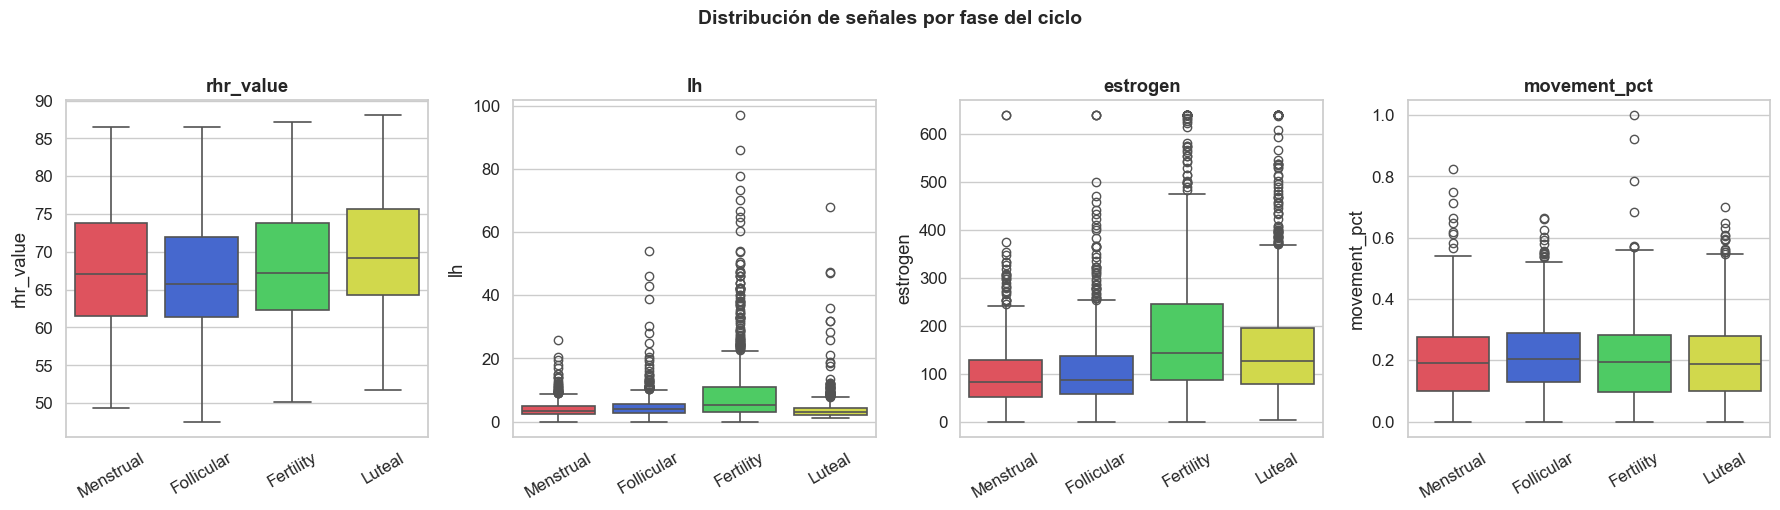

In [7]:
# ── Boxplots: señales clave por fase ─────────────────────────────────────────
signals_to_plot = ['rhr_value', 'lh', 'estrogen', 'movement_pct']
phase_order = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']

fig, axes = plt.subplots(1, len(signals_to_plot), figsize=(18, 5))
for ax, sig in zip(axes, signals_to_plot):
    data_plot = df_clean.dropna(subset=['phase', sig])
    present_phases = [p for p in phase_order if p in data_plot['phase'].unique()]
    palette = {p: PHASE_COLORS.get(p, 'gray') for p in present_phases}
    sns.boxplot(data=data_plot, x='phase', y=sig, order=present_phases,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(sig, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de señales por fase del ciclo', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'boxplot_por_fase.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. DTW entre sujetos (matriz 42×42) + Clustering + UMAP

In [8]:
# ── Preparar series temporales multivariadas por sujeto ──────────────────────
MV_SIGNALS = ['rhr_value', 'hr_pc1', 'hr_pc2', 'lh', 'estrogen',
              'movement_pct', 'wtmp_pc1'] # evitar señales con muchos NaN

# Longitud fija para normalizar series (interpolación a N_POINTS)
N_POINTS = 60

subjects = sorted(df_clean['id'].unique())
print(f'Sujetos encontrados: {len(subjects)}')

def get_subject_series(subject_id, signals=MV_SIGNALS, n_points=N_POINTS):
    """Devuelve array (n_points, n_signals) normalizado para un sujeto."""
    sub = df_clean[df_clean['id'] == subject_id].sort_values('day_in_study')
    days = sub['day_in_study'].values.astype(float)
    grid = np.linspace(days.min(), days.max(), n_points)
    arr = []
    for sig in signals:
        vals = sub[sig].values.astype(float)
        # Rellenar NaN restantes con media
        mask = np.isnan(vals)
        if mask.all():
            arr.append(np.zeros(n_points))
            continue
        vals[mask] = np.nanmean(vals)
        f = interp1d(days, vals, kind='linear', fill_value='extrapolate')
        interp_vals = f(grid)
        # Estandarizar
        mu, sd = interp_vals.mean(), interp_vals.std()
        interp_vals = (interp_vals - mu) / (sd + 1e-8)
        arr.append(interp_vals)
    return np.column_stack(arr)  # (N_POINTS, n_signals)

series_dict = {sid: get_subject_series(sid) for sid in subjects}
print(f'Ejemplo shape: {series_dict[subjects[0]].shape}')

Sujetos encontrados: 42
Ejemplo shape: (60, 7)


### DTW multivariado

In [9]:
# ── Calcular matriz DTW multivariada ─────────────────────────────────────────
# dtw_ndim.distance calcula DTW sobre series multidimensionales
n = len(subjects)
dtw_matrix = np.zeros((n, n))

print(f'Calculando DTW {n}×{n}...')
for i in range(n):
    for j in range(i + 1, n):
        s1 = series_dict[subjects[i]].astype(np.double)
        s2 = series_dict[subjects[j]].astype(np.double)
        d = dtw_ndim.distance(s1, s2)
        dtw_matrix[i, j] = d
        dtw_matrix[j, i] = d
    if i % 5 == 0:
        print(f'  Sujeto {i+1}/{n}')

print('✓ Matriz DTW calculada')
print(f'  Min: {dtw_matrix[dtw_matrix > 0].min():.2f}  Max: {dtw_matrix.max():.2f}')

Calculando DTW 42×42...
  Sujeto 1/42
  Sujeto 6/42
  Sujeto 11/42
  Sujeto 16/42
  Sujeto 21/42
  Sujeto 26/42
  Sujeto 31/42
  Sujeto 36/42
  Sujeto 41/42
✓ Matriz DTW calculada
  Min: 20.11  Max: 28.99


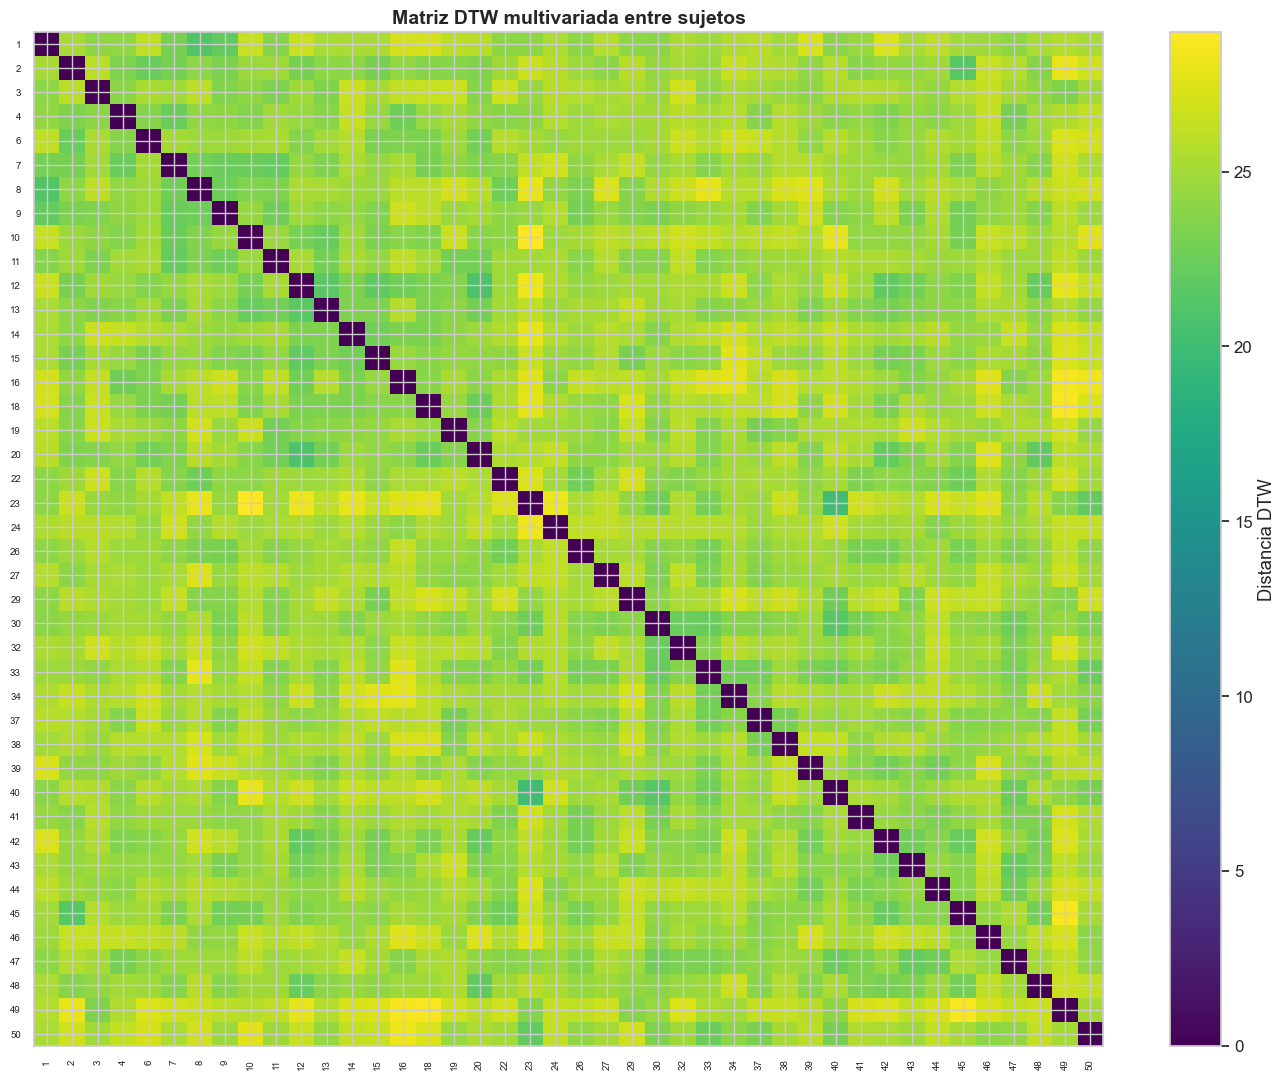

In [10]:
# ── Heatmap de la matriz DTW ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(dtw_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='Distancia DTW')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([str(s) for s in subjects], rotation=90, fontsize=7)
ax.set_yticklabels([str(s) for s in subjects], fontsize=7)
ax.set_title('Matriz DTW multivariada entre sujetos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'dtw_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Clustering jerárquico sobre DTW ──────────────────────────────────────────
# Convertir matriz de distancias a forma condensada
from scipy.spatial.distance import squareform

dtw_condensed = squareform(dtw_matrix)
Z = linkage(dtw_condensed, method='ward')

# Selección de k óptimo por silhouette
sil_scores = {}
for k in range(2, min(10, n)):
    labels = fcluster(Z, k, criterion='maxclust')
    sil_scores[k] = silhouette_score(dtw_matrix, labels, metric='precomputed')

k_opt = max(sil_scores, key=sil_scores.get)
print(f'Scores silhouette: {sil_scores}')
print(f'k óptimo: {k_opt}  (silhouette={sil_scores[k_opt]:.3f})')

cluster_labels = fcluster(Z, k_opt, criterion='maxclust')

Scores silhouette: {2: 0.03853185559164583, 3: 0.02648601324716243, 4: 0.025660957022396975, 5: 0.028512548649221998, 6: 0.028355791148441906, 7: 0.02752525437828147, 8: 0.026455284961756326, 9: 0.028526704862063466}
k óptimo: 2  (silhouette=0.039)


### Dendrograma

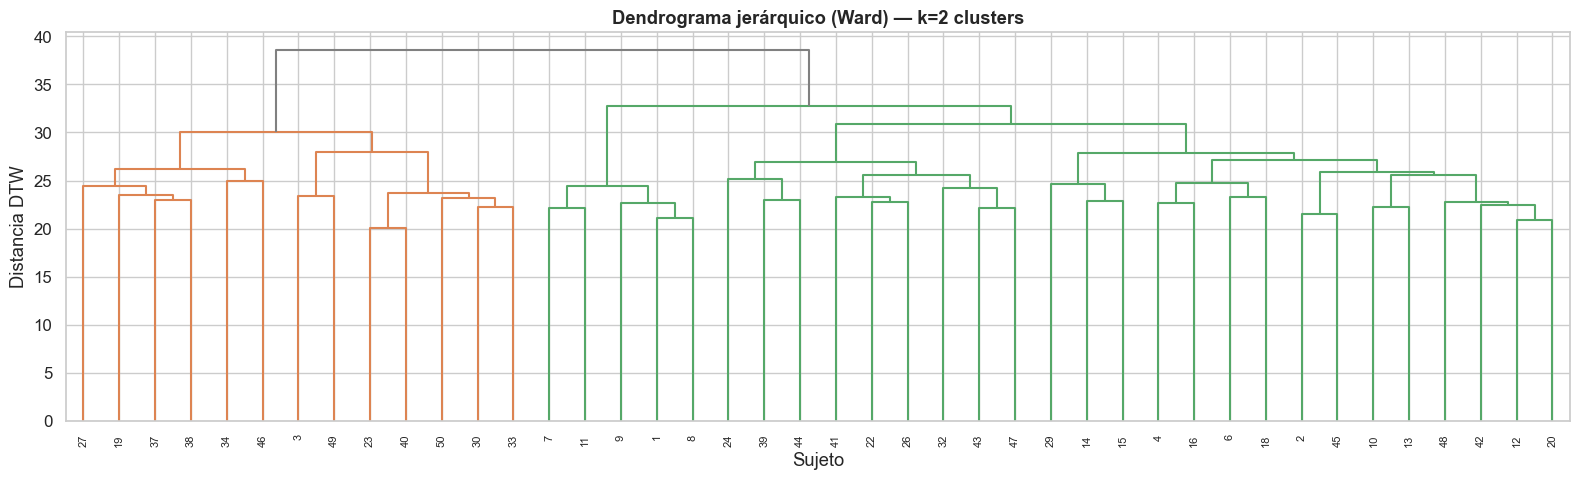

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, labels=[str(s) for s in subjects],
           color_threshold=Z[-(k_opt-1), 2],
           above_threshold_color='gray', ax=ax)
ax.set_title(f'Dendrograma jerárquico (Ward) — k={k_opt} clusters', fontweight='bold')
ax.set_xlabel('Sujeto')
ax.set_ylabel('Distancia DTW')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

### t-SNE

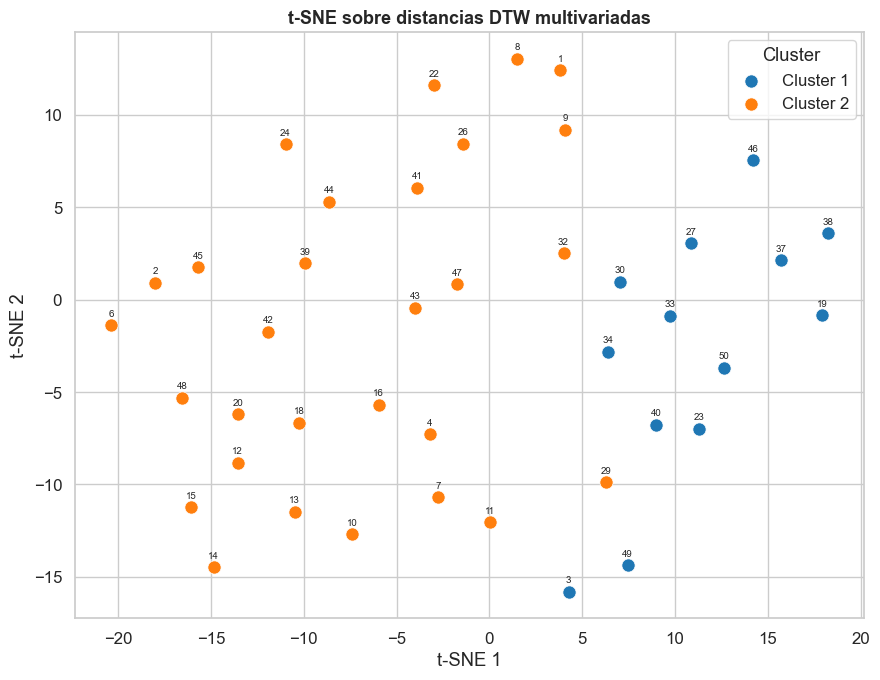

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── t-SNE sobre matriz de distancias DTW ─────────────────────────────────────

tsne = TSNE(
    n_components=2,
    metric='precomputed',
    perplexity=10,
    init='random',
    learning_rate='auto',
    random_state=42
)

embedding = tsne.fit_transform(dtw_matrix)

# ── Plot ─────────────────────────────────────────────────────────────────────

palette = sns.color_palette('tab10', k_opt)

fig, ax = plt.subplots(figsize=(9, 7))

for k in range(1, k_opt + 1):
    mask = cluster_labels == k

    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=[palette[k - 1]],
        label=f'Cluster {k}',
        s=90,
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )

    for idx in np.where(mask)[0]:
        ax.annotate(
            str(subjects[idx]),
            (embedding[idx, 0], embedding[idx, 1]),
            fontsize=7,
            ha='center',
            va='bottom',
            xytext=(0, 5),
            textcoords='offset points'
        )

ax.set_title(
    't-SNE sobre distancias DTW multivariadas',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

ax.legend(title='Cluster')

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / 'tsne_clusters.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### UMAP

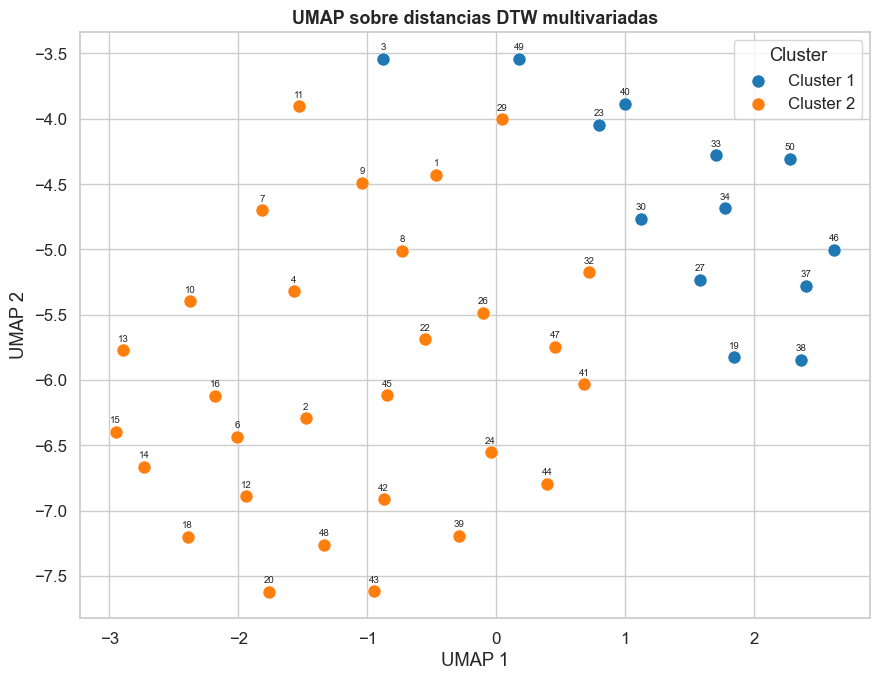

In [14]:
reducer = umap.UMAP(
    metric='precomputed',
    n_components=2,
    n_neighbors=min(10, n - 1),
    min_dist=0.3,
    random_state=42
)
embedding = reducer.fit_transform(dtw_matrix)

# Plot
palette = sns.color_palette('tab10', k_opt)
fig, ax = plt.subplots(figsize=(9, 7))
for k in range(1, k_opt + 1):
    mask = cluster_labels == k
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=[palette[k - 1]], label=f'Cluster {k}',
               s=90, edgecolors='white', linewidths=0.5, zorder=3)
    for idx in np.where(mask)[0]:
        ax.annotate(str(subjects[idx]),
                    (embedding[idx, 0], embedding[idx, 1]),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

ax.set_title('UMAP sobre distancias DTW multivariadas', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Tabla sujeto → cluster ────────────────────────────────────────────────────
subject_clusters = pd.DataFrame({'id': subjects, 'cluster': cluster_labels})
print(subject_clusters.groupby('cluster')['id'].apply(list).to_string())
subject_clusters.to_csv('subject_clusters.csv', index=False)
subject_clusters.head(10)

cluster
1    [3, 19, 23, 27, 30, 33, 34, 37, 38, 40, 46, 49...
2    [1, 2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...


,id,cluster
0,1,2
1,2,2
2,3,1
3,4,2
4,6,2
5,7,2
6,8,2
7,9,2
8,10,2
9,11,2


## 4. DTW entre señales por sujeto (desfases hormonales)

In [16]:
def dtw_pair_distance(subject_id, sig_a='lh', sig_b='rhr_value'):
    """Calcula DTW univariado entre dos señales de un mismo sujeto."""
    sub = df_clean[df_clean['id'] == subject_id].sort_values('day_in_study')
    a = sub[sig_a].dropna().values.astype(np.double)
    b = sub[sig_b].dropna().values.astype(np.double)
    # Estandarizar antes de comparar
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    if len(a) < 3 or len(b) < 3:
        return np.nan
    return dtw.distance(a, b)


# ── Calcular DTW LH ↔ RHR para todos los sujetos ─────────────────────────────
signal_pairs = [
    ('lh', 'rhr_value'),
    ('lh', 'estrogen'),
    ('estrogen', 'rhr_value'),
    ('lh', 'hr_pc1'),
    ('estrogen', 'wtmp_pc1'),
]

dtw_signal_results = []
for sid in subjects:
    row = {'id': sid, 'cluster': subject_clusters.set_index('id').loc[sid, 'cluster']}
    for sa, sb in signal_pairs:
        row[f'{sa}_vs_{sb}'] = dtw_pair_distance(sid, sa, sb)
    dtw_signal_results.append(row)

dtw_signals_df = pd.DataFrame(dtw_signal_results)
print('Estadísticas de DTW por par de señales:')
dtw_signals_df.describe()

Estadísticas de DTW por par de señales:


,id,cluster,lh_vs_rhr_value,lh_vs_estrogen,estrogen_vs_rhr_value,lh_vs_hr_pc1,estrogen_vs_wtmp_pc1
count,42.000000,42.000000,42.000000,42.000000,42.000000,41.000000,42.000000
mean,25.642857,1.690476,8.726233,6.777945,7.548664,8.127508,7.783255
std,15.350890,0.467901,1.179346,1.130736,0.935189,1.237515,1.202795
min,1.000000,1.000000,5.822056,3.761159,5.791068,5.397677,5.494259
25%,12.250000,1.000000,8.091586,6.119886,7.036088,7.305437,7.075150
50%,25.000000,2.000000,8.638245,6.716384,7.497954,8.332231,7.708344
75%,39.750000,2.000000,9.453384,7.314728,7.828508,9.107079,8.072882
max,50.000000,2.000000,12.098811,9.776065,9.917091,10.286613,13.067443


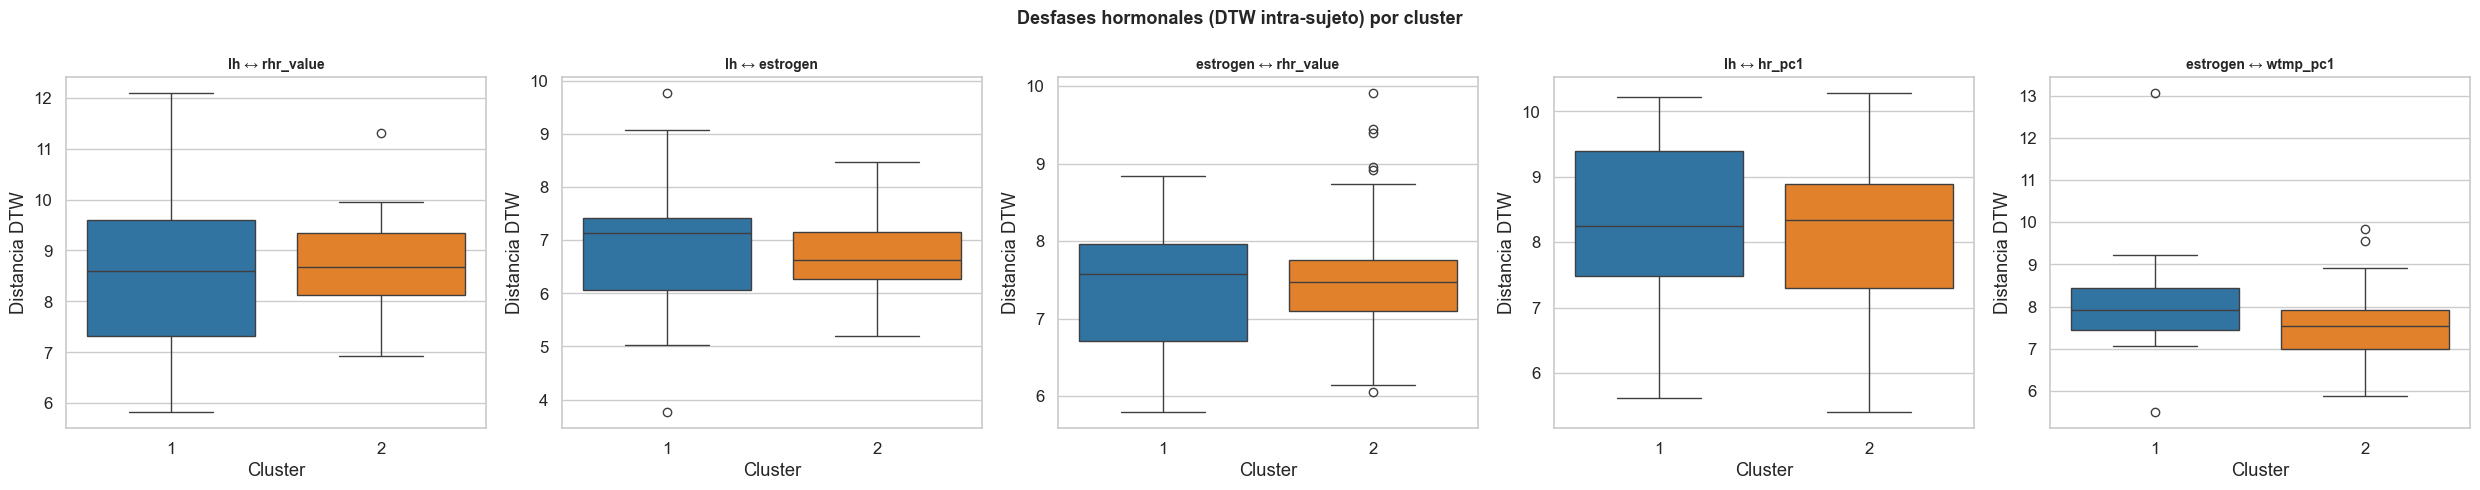

In [17]:
# ── Visualización: distribución de DTW LH↔RHR por cluster ────────────────────
pair_cols = [c for c in dtw_signals_df.columns if '_vs_' in c]

fig, axes = plt.subplots(1, len(pair_cols), figsize=(5 * len(pair_cols), 5))
if len(pair_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, pair_cols):
    sns.boxplot(data=dtw_signals_df, x='cluster', y=col,
                palette='tab10', ax=ax)
    ax.set_title(col.replace('_vs_', ' ↔ '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Distancia DTW')

plt.suptitle('Desfases hormonales (DTW intra-sujeto) por cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'dtw_signal_pairs_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

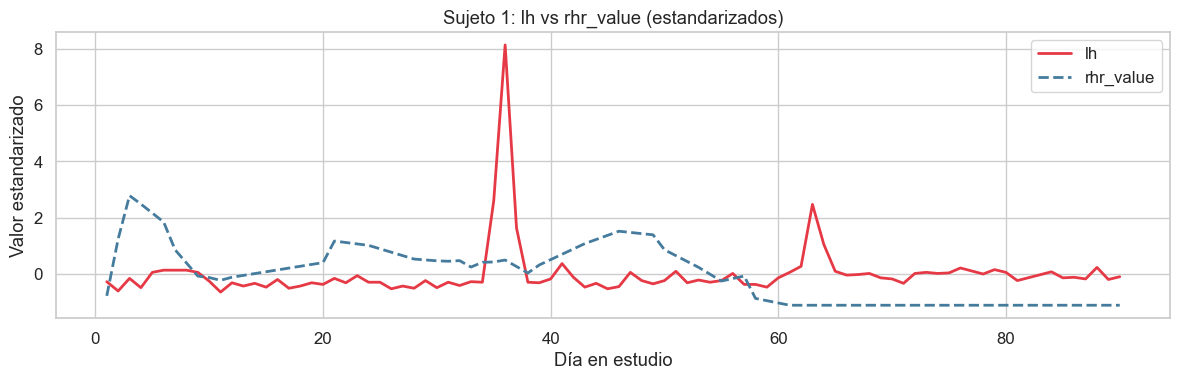

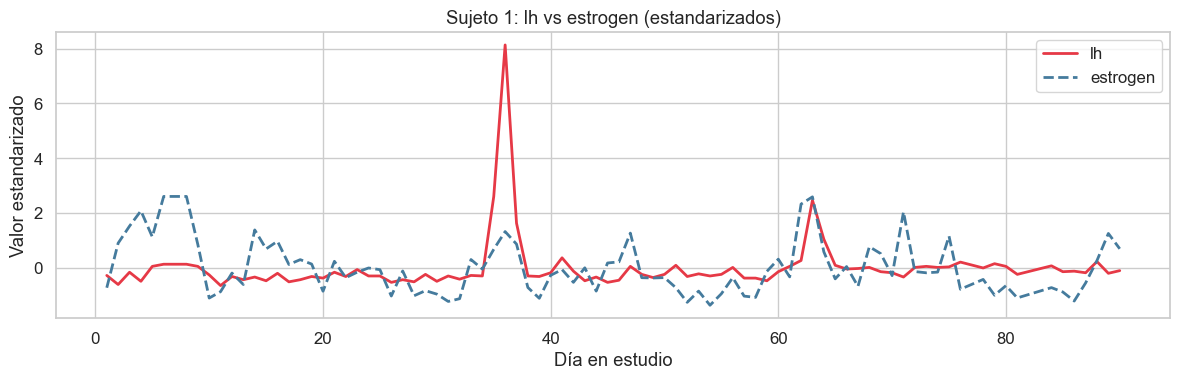

In [18]:
# ── Alineación DTW visual para un sujeto ejemplo ─────────────────────────────
def plot_dtw_alignment(subject_id, sig_a='lh', sig_b='rhr_value'):
    from dtaidistance import dtw_visualisation as dtwvis

    sub = df_clean[df_clean['id'] == subject_id].sort_values('day_in_study')
    days = sub['day_in_study'].values
    a_raw = sub[sig_a].values.astype(float)
    b_raw = sub[sig_b].values.astype(float)

    # Estandarizar
    a = (a_raw - np.nanmean(a_raw)) / (np.nanstd(a_raw) + 1e-8)
    b = (b_raw - np.nanmean(b_raw)) / (np.nanstd(b_raw) + 1e-8)

    # Reemplazar NaN con interpolación lineal simple
    def fill_nan(arr):
        idx = np.arange(len(arr))
        mask = ~np.isnan(arr)
        if mask.sum() < 2:
            return np.zeros(len(arr))
        return np.interp(idx, idx[mask], arr[mask])

    a = fill_nan(a).astype(np.double)
    b = fill_nan(b).astype(np.double)

    # Plot superpuesto
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(days[:len(a)], a, label=sig_a, lw=2, color='#E63946')
    ax.plot(days[:len(b)], b, label=sig_b, lw=2, color='#457B9D', ls='--')
    ax.set_xlabel('Día en estudio')
    ax.set_ylabel('Valor estandarizado')
    ax.set_title(f'Sujeto {subject_id}: {sig_a} vs {sig_b} (estandarizados)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / f'alignment_subj{subject_id}_{sig_a}_vs_{sig_b}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Ejemplo: primer sujeto disponible
example_subject = subjects[0]
plot_dtw_alignment(example_subject, 'lh', 'rhr_value')
plot_dtw_alignment(example_subject, 'lh', 'estrogen')

## 5. Enfasamiento de ciclos

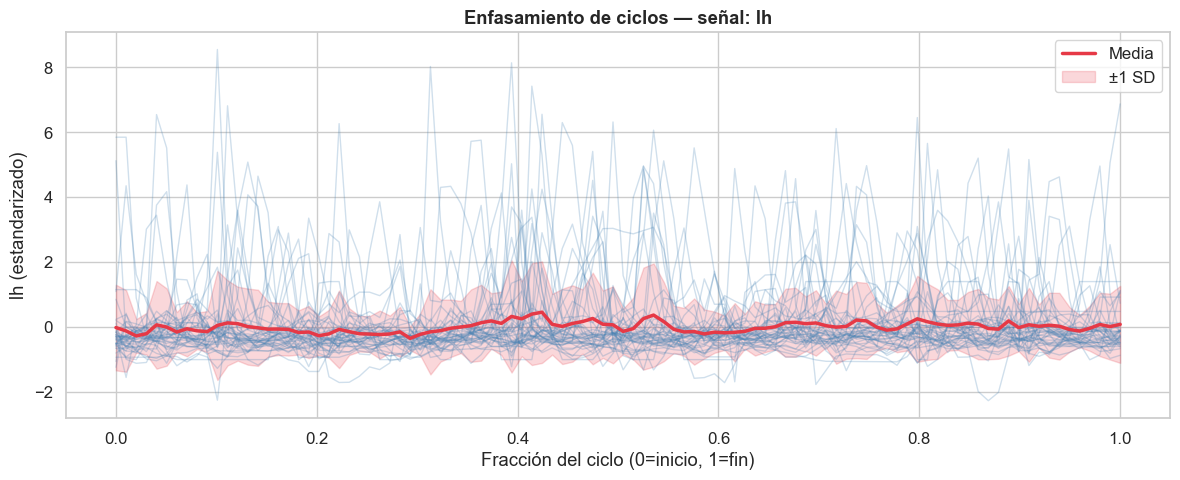

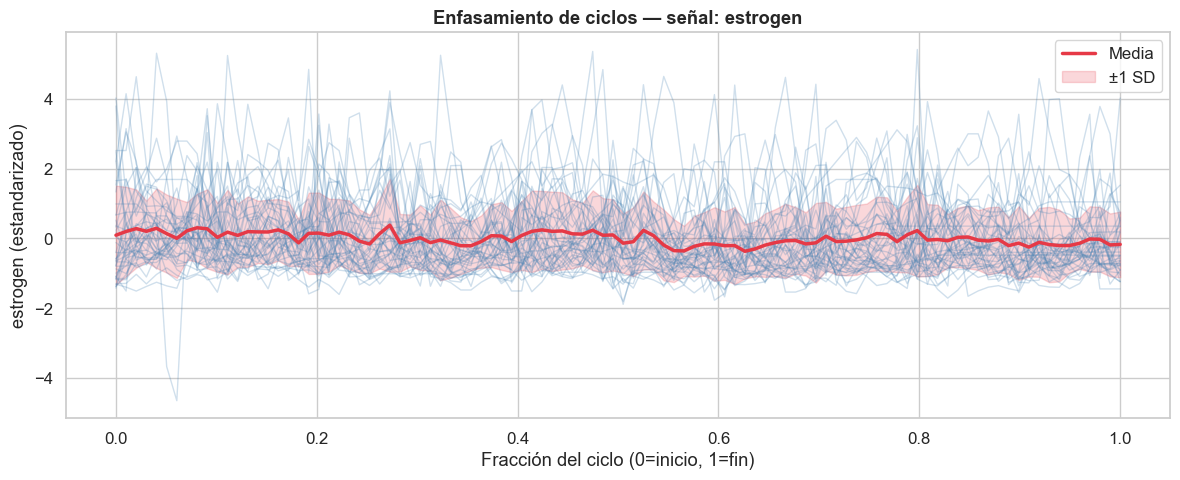

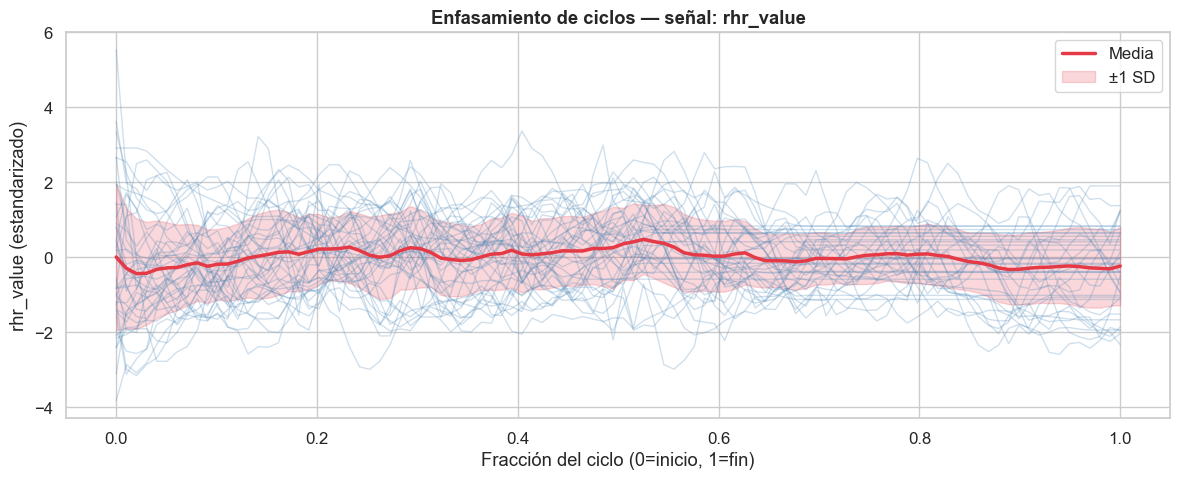

In [19]:
# ── Normalizar cada ciclo a [0, 1] usando la columna 'phase' ─────────────────
# Asignar orden numérico a las fases
PHASE_ORDER = {'Menstrual': 0, 'Follicular': 1, 'Fertility': 2, 'Luteal': 3}

def normalize_cycle(subject_id, signal='lh', n_points=100):
    """Interpola la señal de un sujeto a n_points en [0,1] (tiempo de ciclo normalizado)."""
    sub = df_clean[df_clean['id'] == subject_id].sort_values('day_in_study')
    vals = sub[signal].values.astype(float)
    days = sub['day_in_study'].values.astype(float)

    mask = ~np.isnan(vals)
    if mask.sum() < 4:
        return None, None

    # Normalizar días a [0, 1]
    t_norm = (days - days.min()) / (days.max() - days.min() + 1e-8)
    grid = np.linspace(0, 1, n_points)

    f = interp1d(t_norm[mask], vals[mask], kind='linear', fill_value='extrapolate')
    interp_vals = f(grid)
    return grid, interp_vals


# ── Plot: ciclos individuales + media ─────────────────────────────────────────
def plot_cycle_alignment(signal='lh', n_points=100, max_subjects=None):
    subs = subjects if max_subjects is None else subjects[:max_subjects]
    fig, ax = plt.subplots(figsize=(12, 5))
    all_curves = []

    for sid in subs:
        grid, curve = normalize_cycle(sid, signal, n_points)
        if curve is None:
            continue
        # Estandarizar por sujeto para comparar forma
        c_std = (curve - np.nanmean(curve)) / (np.nanstd(curve) + 1e-8)
        ax.plot(grid, c_std, alpha=0.25, lw=1, color='steelblue')
        all_curves.append(c_std)

    if all_curves:
        mean_curve = np.nanmean(all_curves, axis=0)
        std_curve = np.nanstd(all_curves, axis=0)
        ax.plot(grid, mean_curve, color='#E63946', lw=2.5, label='Media')
        ax.fill_between(grid, mean_curve - std_curve, mean_curve + std_curve,
                        alpha=0.2, color='#E63946', label='±1 SD')

    ax.set_xlabel('Fracción del ciclo (0=inicio, 1=fin)')
    ax.set_ylabel(f'{signal} (estandarizado)')
    ax.set_title(f'Enfasamiento de ciclos — señal: {signal}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / f'cycle_alignment_{signal}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_cycle_alignment('lh')
plot_cycle_alignment('estrogen')
plot_cycle_alignment('rhr_value')

## 6. Perfiles medios por cluster y fase

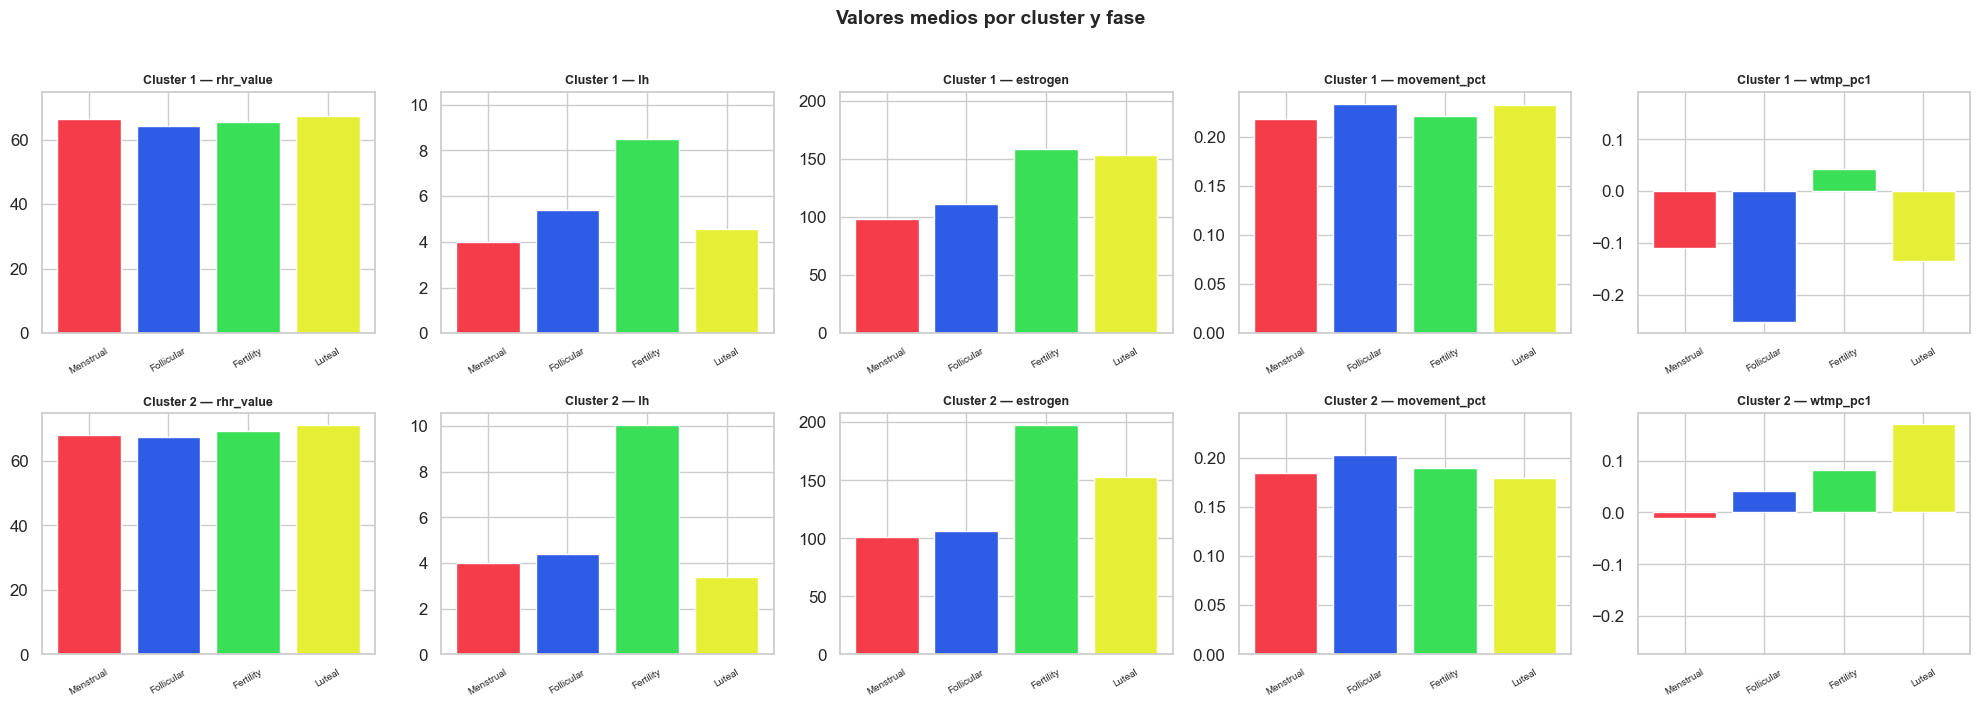

In [20]:
# Agregar cluster a df_clean
df_clean = df_clean.merge(subject_clusters, on='id', how='left')

signals_key = ['rhr_value', 'lh', 'estrogen', 'movement_pct', 'wtmp_pc1']
phase_cluster_means = (
    df_clean.dropna(subset=['phase'])
            .groupby(['cluster', 'phase'])[signals_key]
            .mean()
            .reset_index()
)

phase_order_plot = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']

n_clusters = phase_cluster_means['cluster'].nunique()
fig, axes = plt.subplots(n_clusters, len(signals_key),
                          figsize=(4 * len(signals_key), 3.5 * n_clusters),
                          sharey='col')

if n_clusters == 1:
    axes = [axes]

for ci, clust in enumerate(sorted(phase_cluster_means['cluster'].unique())):
    sub_data = phase_cluster_means[phase_cluster_means['cluster'] == clust]
    for si, sig in enumerate(signals_key):
        ax = axes[ci][si]
        phases_available = [p for p in phase_order_plot if p in sub_data['phase'].values]
        vals = sub_data.set_index('phase').loc[phases_available, sig]
        colors = [PHASE_COLORS.get(p, 'gray') for p in phases_available]
        ax.bar(phases_available, vals.values, color=colors, edgecolor='white')
        ax.set_title(f'Cluster {clust} — {sig}', fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Valores medios por cluster y fase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'cluster_phase_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumen y exportación

In [21]:
# ── Guardar resultados principales ───────────────────────────────────────────
np.save(output_path / 'hdtw_matrix.npy', dtw_matrix)
dtw_signals_df.to_csv(output_path / 'dtw_signal_pairs.csv', index=False)
phase_means.to_csv(output_path / 'phase_means_per_subject.csv', index=False)
phase_cluster_means.to_csv(output_path / 'phase_cluster_means.csv', index=False)

print('Archivos guardados:')
print('  dtw_matrix.npy              — Matriz DTW multivariada')
print('  subject_clusters.csv        — Asignación sujeto→cluster')
print('  dtw_signal_pairs.csv        — DTW intra-sujeto por par de señales')
print('  phase_means_per_subject.csv — Media por sujeto y fase')
print('  phase_cluster_means.csv     — Media por cluster y fase')
print()
print('Figuras generadas:')
for fname in ['boxplot_por_fase.png', 'dtw_matrix_heatmap.png', 'dendrogram.png',
              'umap_clusters.png', 'dtw_signal_pairs_by_cluster.png',
              'cycle_alignment_lh.png', 'cycle_alignment_estrogen.png',
              'cycle_alignment_rhr_value.png', 'cluster_phase_profiles.png']:
    print(f'  {fname}')

NameError: name 'output_path' is not defined